# El universo no se ve igual en todas las direcciones (hasta donde alcanzamos a mirar)

El principio cosmológico —la base sobre la que se construye casi toda la cosmología— dice que, si te alejas lo suficiente, el universo debería verse parejo: la misma cantidad de galaxias hacia donde mires, sin direcciones privilegiadas. Un equipo puso a prueba ese supuesto con un mapa de **150.136 galaxias** del cartografiado DESI. Y encontró hilos y direcciones que persisten hasta escalas de **un gigaparsec** (mil millones de pársecs).

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Detection of anisotropic cosmic structures on a gigaparsec scale* — Sylos Labini & Galoppo, *Nature* (2026).
**DOI:** [10.1038/s41586-026-10702-5](https://doi.org/10.1038/s41586-026-10702-5)
**Datos:** DESI DR1 (BGS + LRGS) vía [Zenodo](https://zenodo.org/records/20118015).

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-24-anisotropia-cosmica-gigaparsec/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/HdNMtY8i86g)

## ¿Qué midieron, y por qué cuesta?

El cartografiado DESI mapea la posición tridimensional de millones de galaxias. Aquí trabajamos con cinco recortes de ese mapa, ordenados por profundidad: desde el vecindario cósmico (**S1**) hasta una lámina que llega a **~1 Gpc/h** de distancia comóvil (**LRGS**). Cada recorte es una "rebanada" fina (un slab cuasi-bidimensional), así que podemos verlo casi como un mapa plano del cielo.

La pregunta del paper: ¿las galaxias se reparten sin dirección preferida (isotropía), o hay orientaciones que se repiten a lo largo de toda la rebanada? Para responderlo, el equipo usó el **ADPD** (*Angular Distribution of Pairwise Distances*), un estadístico sin parámetros libres que mide correlaciones direccionales. Nosotros no podemos recalcular el ADPD con estos datos, pero sí podemos construir un proxy didáctico que ilustra el concepto.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
R_MIN, R_MAX = 100.0, 300.0     # ventana de separación de pares (Mpc/h) del proxy direccional
N_SUB   = 2500                  # galaxias por muestra para el proxy (submuestreo reproducible)
N_PARES = 20000                 # presupuesto FIJO de pares -> ruido isotrópico comparable entre muestras
N_BINS  = 18                    # bins del histograma de orientaciones (0-180 grados)
N_NULL  = 300                   # realizaciones isotrópicas que forman la nube de control
SEED    = 42

COLOR_DATOS     = '#2563EB'     # azul CaM
COLOR_ALERTA    = '#DC2626'     # rojo
COLOR_REFERENCIA= '#D97706'     # ámbar
COLOR_CONTEXTO  = '#BBBBBB'     # gris
FUENTE = 'Fuente: Sylos Labini & Galoppo (2026), Nature | Datos: DESI DR1 via Zenodo'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local -> /tmp -> GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de las 5 muestras (coordenadas comóviles x, y, z en Mpc/h)
MUESTRAS = [('S1',   'datos/galaxias_S1.csv'),
            ('S2',   'datos/galaxias_S2.csv'),
            ('S3',   'datos/galaxias_S3.csv'),
            ('S4',   'datos/galaxias_S4.csv'),
            ('LRGS', 'datos/galaxias_LRGS.csv')]

datos, rmax = {}, {}
total = 0
print(f"{'muestra':8} {'galaxias':>9} {'r_max (Mpc/h)':>14} {'r_medio':>9}")
for nombre, f in MUESTRAS:
    df = pd.read_csv(f)
    r = np.sqrt(df.x_mpch**2 + df.y_mpch**2 + df.z_mpch**2)
    datos[nombre] = df
    rmax[nombre]  = r.max()
    total += len(df)
    print(f"{nombre:8} {len(df):9d} {r.max():14.1f} {r.mean():9.1f}")

print(f"\nTotal: {total:,} galaxias en 5 muestras".replace(',', '.'))
print(f"La muestra más profunda (LRGS) llega a {rmax['LRGS']/1000:.2f} Gpc/h "
      f"(~{rmax['LRGS']*3.26/1000:.1f} mil millones de años luz comóviles)")

muestra   galaxias  r_max (Mpc/h)   r_medio
S1           27685          194.0     132.2
S2           36290          292.7     179.7
S3           48291          434.5     280.7
S4           29109          627.8     419.4
LRGS          8761         1004.5     671.2

Total: 150.136 galaxias en 5 muestras
La muestra más profunda (LRGS) llega a 1.00 Gpc/h (~3.3 mil millones de años luz comóviles)


## Aquí está el cosmos cercano

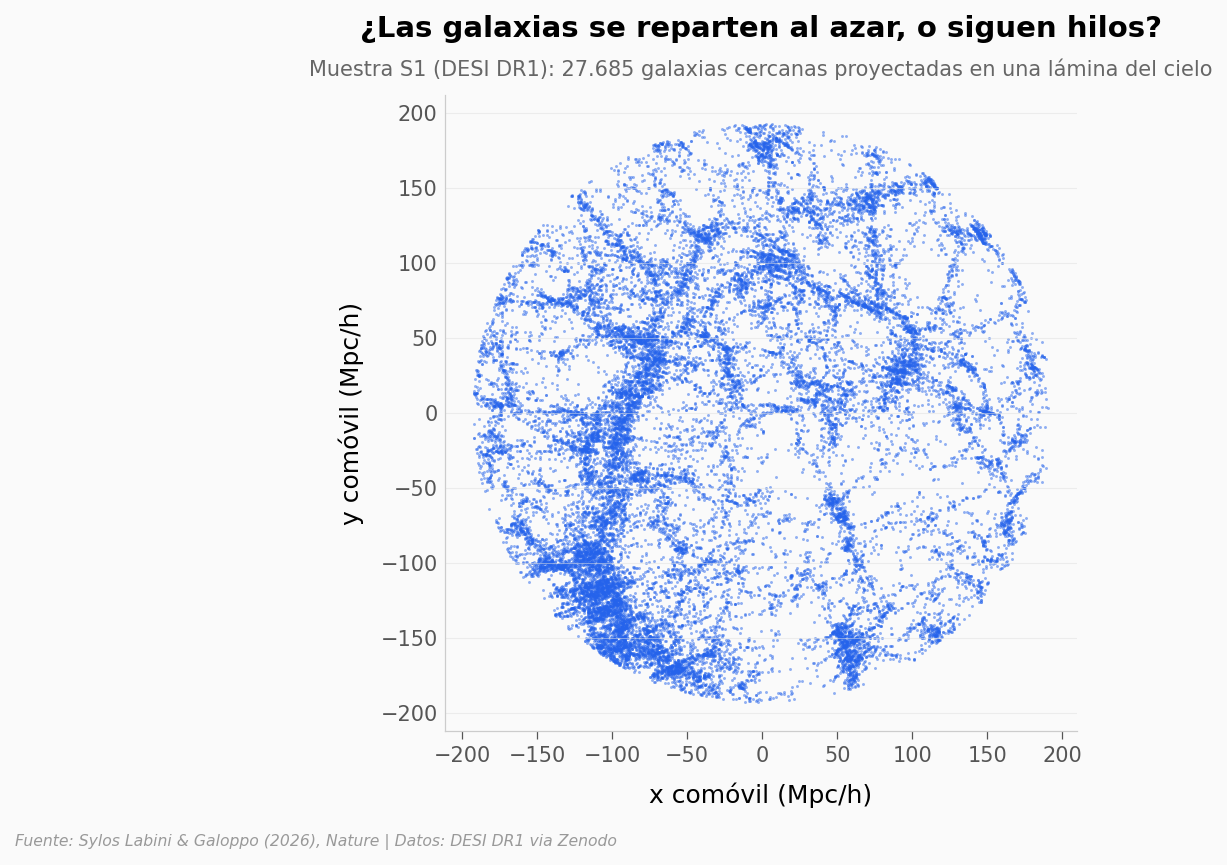

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))
df = datos['S1']
ax.scatter(df.x_mpch, df.y_mpch, s=2, color=COLOR_DATOS, alpha=0.5, linewidths=0)

ax.set_title('¿Las galaxias se reparten al azar, o siguen hilos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Muestra S1 (DESI DR1): {len(df):,} galaxias cercanas proyectadas en una lámina del cielo'.replace(',', '.'),
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('x comóvil (Mpc/h)')
ax.set_ylabel('y comóvil (Mpc/h)')
ax.set_aspect('equal')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_cosmic_web.png', dpi=200, bbox_inches='tight')
plt.show()

Las galaxias no caen como sal espolveada al azar: se enhebran en filamentos y dejan huecos vacíos entre medio. Esa textura —la *telaraña cósmica*— es justo lo que esperamos a escalas pequeñas. La pregunta interesante es otra: ¿esa textura tiene **direcciones preferidas** que se repiten por toda la lámina, o las orientaciones de los hilos apuntan a cualquier lado por igual?

## ¿Y si nos alejamos hasta el borde del mapa?

S1 es el vecindario. Pero el supuesto de isotropía es sobre las **grandes** escalas: cuanto más lejos miramos, más debería desaparecer cualquier dirección privilegiada. Veamos las cinco profundidades, de S1 (cerca) a LRGS (~1 Gpc/h).

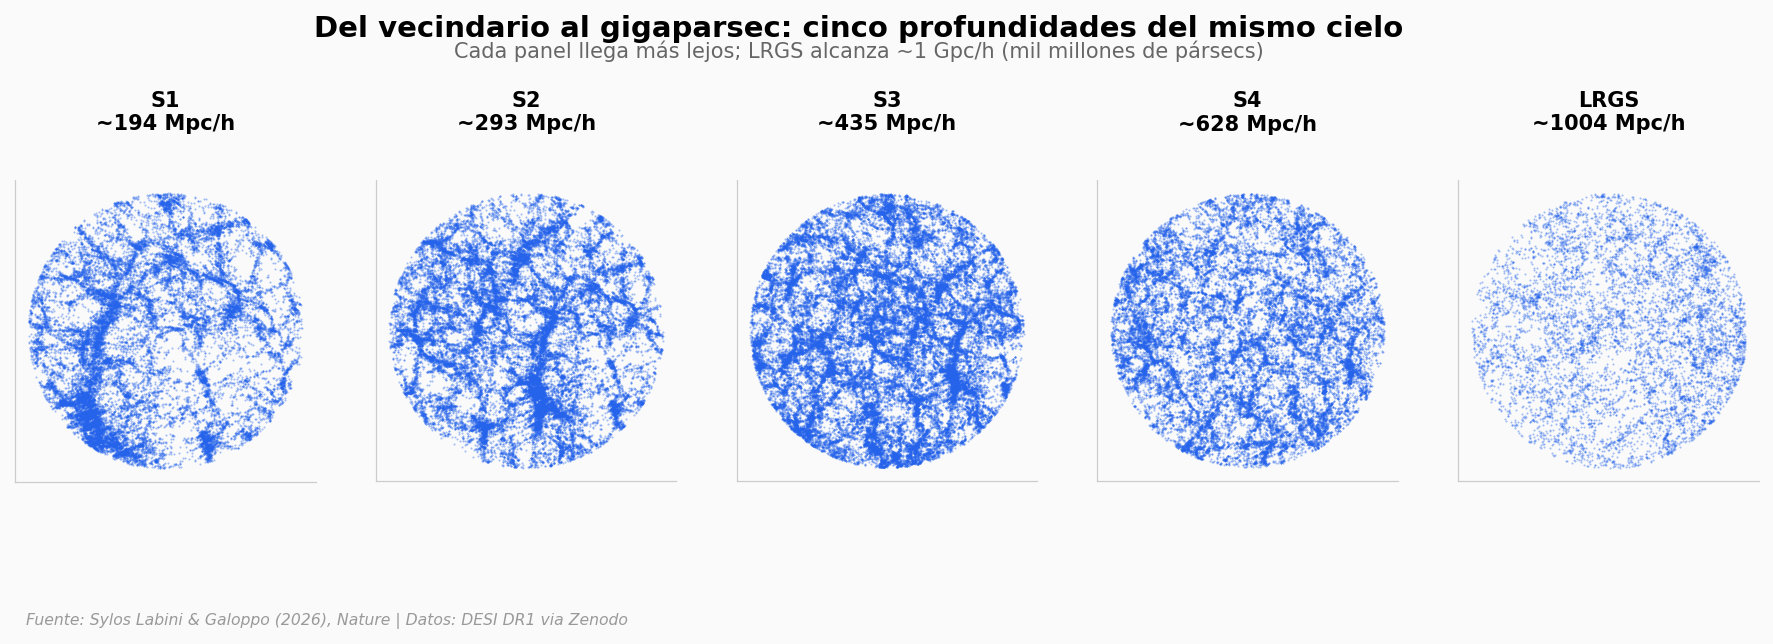

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3.6))
for ax, (nombre, _) in zip(axes, MUESTRAS):
    df = datos[nombre]
    ax.scatter(df.x_mpch, df.y_mpch, s=1, color=COLOR_DATOS, alpha=0.4, linewidths=0)
    ax.set_title(f'{nombre}\n~{rmax[nombre]:.0f} Mpc/h', fontsize=10, fontweight='bold')
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle('Del vecindario al gigaparsec: cinco profundidades del mismo cielo',
             fontsize=14, fontweight='bold', y=1.08)
fig.text(0.5, 1.0, 'Cada panel llega más lejos; LRGS alcanza ~1 Gpc/h (mil millones de pársecs)',
         ha='center', fontsize=10, color='#666666')
fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/panorama_profundidad.png', dpi=200, bbox_inches='tight')
plt.show()

## Midamos la dirección

Para cada muestra tomamos pares de galaxias separadas entre 100 y 300 Mpc/h y anotamos la **orientación** de cada par (el ángulo de la línea que las une, de 0 a 180 grados). Si el cielo fuera isotrópico, todas las orientaciones serían igual de frecuentes: el histograma saldría plano. Si hay direcciones preferidas, aparecen picos.

Comparamos la dispersión de ese histograma real contra una **nube isotrópica** de control: los mismos pares, pero con sus ángulos barajados al azar.

> ⚠️ Esto es un **proxy didáctico**, no el ADPD del paper. Sirve para *ver* el concepto de anisotropía direccional. La significancia formal (>3σ conservadora) sale del estadístico del paper comparado contra catálogos simulados ΛCDM, no de este cálculo.

S1      20000 pares -> dispersión real/isotrópico = 7.10×


S2      20000 pares -> dispersión real/isotrópico = 1.50×


S3      20000 pares -> dispersión real/isotrópico = 1.17×
S4      20000 pares -> dispersión real/isotrópico = 1.39×


LRGS    20000 pares -> dispersión real/isotrópico = 1.31×


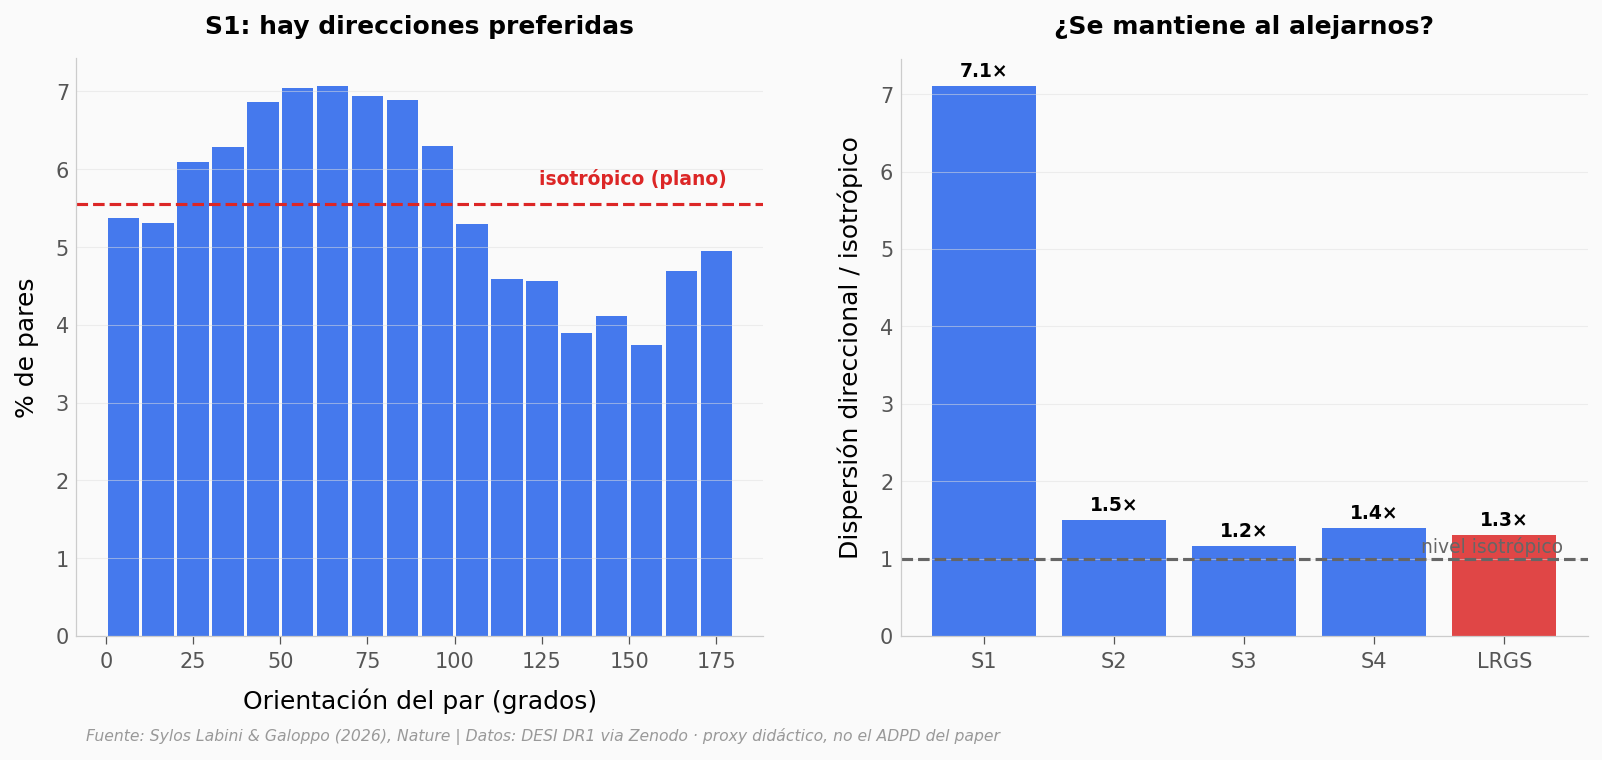

In [4]:
# --- Proxy de anisotropía direccional (métrica DIDÁCTICA, no el ADPD del paper; ver tabla de verificación) ---
def orientaciones(df, rmin=R_MIN, rmax=R_MAX, seed=SEED):
    """Ángulos de orientación (mod 180 grados) de pares separados rmin-rmax Mpc/h,
    en proyección 2D (x, y). Devuelve hasta N_PARES ángulos para igualar el ruido entre muestras.
    Recorre los pares por bloques de filas (no materializa la matriz NxN completa) para
    caber en la memoria del contenedor; el orden de los pares es el de triu (i<j)."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(df), size=min(N_SUB, len(df)), replace=False)
    P = df.iloc[idx][['x_mpch', 'y_mpch']].to_numpy()
    n = len(P)
    partes, CHUNK = [], 200
    for a in range(0, n, CHUNK):
        b = min(a + CHUNK, n)
        dx = P[a:b, 0][:, None] - P[:, 0][None, :]
        dy = P[a:b, 1][:, None] - P[:, 1][None, :]
        d = np.sqrt(dx*dx + dy*dy)
        for r in range(a, b):          # solo pares j > i, en orden creciente
            js = r + 1
            dd = d[r - a, js:]
            m = (dd >= rmin) & (dd <= rmax)
            if m.any():
                partes.append(np.mod(np.arctan2(dy[r - a, js:][m], dx[r - a, js:][m]), np.pi))
    th = np.concatenate(partes) if partes else np.array([])
    if len(th) > N_PARES:
        th = th[rng.choice(len(th), N_PARES, replace=False)]
    return th

def dispersion(theta):
    """Desviación estándar del histograma normalizado de orientaciones.
    Plano (isotrópico) -> dispersión baja; con picos (anisotrópico) -> dispersión alta."""
    h, _ = np.histogram(theta, bins=N_BINS, range=(0, np.pi))
    return np.std(h / h.sum())

rng_null = np.random.default_rng(SEED + 7)
proxy = {}
for nombre, _ in MUESTRAS:
    th = orientaciones(datos[nombre])
    s_real = dispersion(th)
    nulls = np.array([dispersion(rng_null.uniform(0, np.pi, len(th))) for _ in range(N_NULL)])
    proxy[nombre] = {'real': s_real, 'nulls': nulls,
                     'ratio': s_real / nulls.mean(), 'n_pares': len(th)}
    print(f"{nombre:6} {proxy[nombre]['n_pares']:6d} pares -> dispersión real/isotrópico = {proxy[nombre]['ratio']:.2f}×")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: distribución de orientaciones de S1 vs lo isotrópico plano
th1 = orientaciones(datos['S1'])
bins = np.linspace(0, 180, N_BINS + 1)
centers = (bins[:-1] + bins[1:]) / 2
h1, _ = np.histogram(np.degrees(th1), bins=bins)
h1 = h1 / h1.sum() * 100
ax1.bar(centers, h1, width=180 / N_BINS * 0.9, color=COLOR_DATOS, alpha=0.85)
ax1.axhline(100 / N_BINS, color=COLOR_ALERTA, ls='--', lw=1.5)
ax1.text(178, 100 / N_BINS + 0.25, 'isotrópico (plano)', color=COLOR_ALERTA,
         ha='right', fontsize=9, fontweight='bold')
ax1.set_xlabel('Orientación del par (grados)')
ax1.set_ylabel('% de pares')
ax1.set_title('S1: hay direcciones preferidas', fontsize=12, fontweight='bold', pad=12)

# Panel derecho: razón real/isotrópico por muestra (depende de la profundidad)
nombres = [m[0] for m in MUESTRAS]
ratios = [proxy[n]['ratio'] for n in nombres]
colores = [COLOR_ALERTA if n == 'LRGS' else COLOR_DATOS for n in nombres]
ax2.bar(nombres, ratios, color=colores, alpha=0.85)
ax2.axhline(1.0, color='#666666', ls='--', lw=1.5)
ax2.text(4.45, 1.08, 'nivel isotrópico', color='#666666', ha='right', fontsize=9)
for i, rr in enumerate(ratios):
    ax2.text(i, rr + 0.12, f'{rr:.1f}×', ha='center', fontsize=9, fontweight='bold')
ax2.set_ylabel('Dispersión direccional / isotrópico')
ax2.set_title('¿Se mantiene al alejarnos?', fontsize=12, fontweight='bold', pad=12)

fig.text(0.13, -0.03, FUENTE + ' · proxy didáctico, no el ADPD del paper',
         fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/orientacion_y_razon.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan fuera de lo isotrópico está la muestra cercana?

La S1 marcó **7,1×** más dispersión direccional que su control isotrópico. Para ver si eso es mucho o poco, comparémoslo contra la nube entera de simulaciones isotrópicas: 300 universos barajados al azar, cada uno con su propia dispersión por puro ruido.

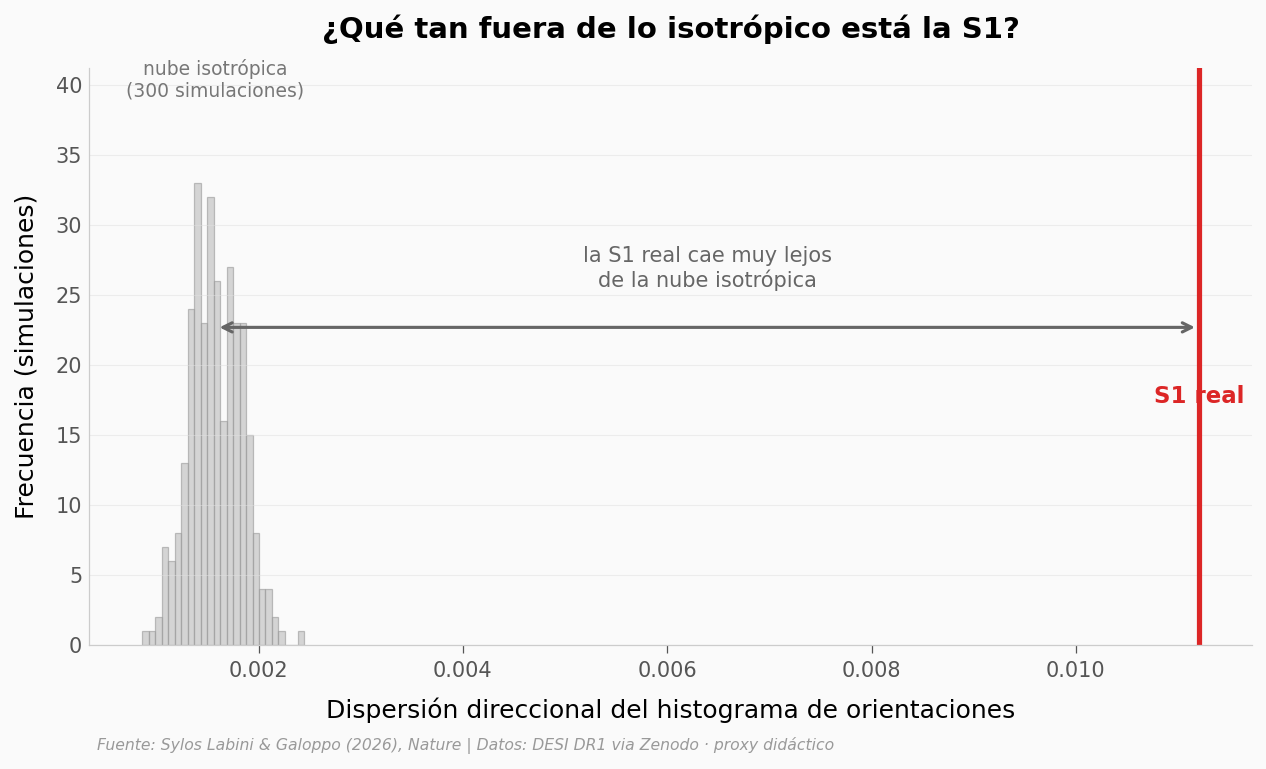

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
nulls = proxy['S1']['nulls']
real = proxy['S1']['real']
mu = nulls.mean()

n, _, _ = ax.hist(nulls, bins=25, color=COLOR_CONTEXTO, alpha=0.6,
                  edgecolor='#999999', linewidth=0.6)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)
ax.axvline(real, color=COLOR_ALERTA, lw=2.5)
ax.annotate('', xy=(real, y_max * 0.55), xytext=(mu, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((real + mu) / 2, y_max * 0.62, 'la S1 real cae muy lejos\nde la nube isotrópica',
        ha='center', fontsize=10, color='#666666')
ax.text(mu, y_max * 0.95, 'nube isotrópica\n(300 simulaciones)',
        ha='center', fontsize=9, color='#777777')
ax.text(real, y_max * 0.42, 'S1 real', ha='center', color=COLOR_ALERTA,
        fontweight='bold', fontsize=11)
ax.set_xlabel('Dispersión direccional del histograma de orientaciones')
ax.set_ylabel('Frecuencia (simulaciones)')
ax.set_title('¿Qué tan fuera de lo isotrópico está la S1?',
             fontsize=14, fontweight='bold', pad=14)

fig.text(0.13, -0.03, FUENTE + ' · proxy didáctico', fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_isotropica.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El mapa reúne 150.136 galaxias en 5 muestras de profundidad creciente | ✅ | Suma directa de los CSV (S1 27.685 · S2 36.290 · S3 48.291 · S4 29.109 · LRGS 8.761) |
| La muestra más profunda (LRGS) llega a ~1 Gpc/h | ✅ | r_max calculado = 1004,5 Mpc/h = 1,00 Gpc/h; coincide con el titular del paper |
| Las galaxias forman filamentos y vacíos, no una nube uniforme | ✅ | Visible en la gráfica hero (S1); textura de telaraña cósmica |
| La muestra cercana tiene direcciones preferidas muy por encima del azar isotrópico | ✅ | Proxy direccional S1 = 7,1× su control; cae fuera de la nube de 300 simulaciones isotrópicas |
| El exceso direccional persiste —más débil— en las muestras profundas | ⚠️ | El proxy baja con la profundidad (S2 1,5× · S3 1,2× · S4 1,4× · LRGS 1,3×). S3 queda casi al nivel isotrópico en este proxy 2D. La persistencia rigurosa a 1 Gpc es del ADPD del paper, no de este proxy |
| La señal contradice el modelo estándar / refuta ΛCDM | ❌ | El paper *reta* el supuesto de isotropía con >3σ conservadora; no refuta ΛCDM. Es un estudio que pide confirmación, no un veredicto |

> **Sobre el proxy:** la "dispersión direccional" de este notebook es una **simplificación didáctica** para *ver* la idea de anisotropía. NO es el ADPD (*Angular Distribution of Pairwise Distances*) del paper, que es un estadístico sin parámetros comparado contra catálogos simulados ΛCDM. Nunca conviertas la razón (×) de este proxy en una significancia σ.

> **Limitaciones:** (1) Trabajamos sobre la proyección 2D de rebanadas finas, no sobre el volumen 3D completo. (2) El proxy depende del submuestreo (2.500 galaxias) y de la ventana de pares (100–300 Mpc/h). (3) Un solo estudio no es la última palabra: 3σ es una señal fuerte, pero el umbral de descubrimiento en física es 5σ — el propio paper la llama "conservadora" y pide reevaluar, no cerrar el tema.

## Ahora tú

1. **¿La dirección preferida cambia con la escala?** En la celda de abajo, mueve la ventana de pares (`50-100`, `100-300`, `300-500` Mpc/h) y observa cómo cambia la dispersión direccional de S1. ¿Las estructuras grandes están tan orientadas como las pequeñas?

2. **¿Y si miras otra muestra?** Cambia `'S1'` por `'LRGS'` en el código: ¿el cosmos profundo conserva direcciones preferidas, o se aplana hacia lo isotrópico?

3. **¿Cuánto pesa el azar?** Sube `N_NULL` a 1.000 simulaciones y vuelve a correr la celda 11: ¿se estrecha la nube isotrópica? ¿Sigue la S1 real igual de lejos?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿La orientación preferida es igual de fuerte a distintas escalas?
MUESTRA = 'S1'          # prueba 'LRGS' para el cosmos profundo
print(f"Muestra {MUESTRA} (dispersión a igual nº de pares):")
for lo, hi in [(50, 100), (100, 300), (300, 500)]:
    th = orientaciones(datos[MUESTRA], rmin=lo, rmax=hi)
    print(f"  pares {lo}-{hi} Mpc/h: {len(th):>6} pares · dispersión direccional = {dispersion(th):.4f}")

Muestra S1 (dispersión a igual nº de pares):
  pares 50-100 Mpc/h:  20000 pares · dispersión direccional = 0.0067


  pares 100-300 Mpc/h:  20000 pares · dispersión direccional = 0.0112
  pares 300-500 Mpc/h:  20000 pares · dispersión direccional = 0.0351


## Créditos

- **Paper:** Sylos Labini, F. & Galoppo, M. *Detection of anisotropic cosmic structures on a gigaparsec scale.* Nature (2026). DOI: [10.1038/s41586-026-10702-5](https://doi.org/10.1038/s41586-026-10702-5)
- **Datos:** muestras de galaxias en [Zenodo](https://zenodo.org/records/20118015), derivadas de los catálogos públicos [DESI DR1](https://data.desi.lbl.gov/doc/releases/dr1/) (BGS + LRGS).
- **Licencia datos:** según los términos de DESI DR1 / Zenodo.
- **Repo:** [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)

## Fuentes

**Paper**: [Detection of anisotropic cosmic structures on a gigaparsec scale](https://doi.org/10.1038/s41586-026-10702-5)  
*Nature, 2026-06-24*

**Datos**: [Detection of anisotropic cosmic structures on a gigaparsec scale: galaxy samples](https://zenodo.org/records/20118015)  
*galaxias DESI DR1 en Zenodo*

**Referencias citadas**: [DESI DR1 galaxy catalogues (BGS + LRGS)](https://data.desi.lbl.gov/doc/releases/dr1/)

*14 afirmaciones del notebook verificadas contra estas fuentes*